In [1]:
# Packages for generating example datasets
import numpy as np
import torch
import torchdyn
from torchdyn.datasets import generate_moons
from scipy.spatial import distance
import matplotlib.pyplot as plt
# Import FRLC packages
import sys
sys.path.insert(0, '../src')
import FRLC.FRLC as frlc
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float64


x0 = np.loadtxt('planted_gaussians_k250_sigma0.1_perturb0.1_n2500_X.txt')
x1 = np.loadtxt('planted_gaussians_k250_sigma0.1_perturb0.1_n2500_Y.txt')

C = distance.cdist(x0, x1)**2
# We recommended normalizing input distance matrices by the max-value for numerical stability and may make this a default.
C = C / C.max()

In [2]:
import jax
import jax.numpy as jnp
import importlib


def _kmeanspp_init_np(X, k, rng):
    X = np.asarray(X, dtype=float)
    n, d = X.shape
    centers = np.empty((k, d), dtype=float)

    i0 = rng.integers(n)
    centers[0] = X[i0]
    d2 = np.sum((X - centers[0])**2, axis=1)

    for t in range(1, k):
        # normalize probs safely
        s = d2.sum()
        if not np.isfinite(s) or s <= 0:
            probs = np.full(n, 1.0/n, dtype=float)
        else:
            probs = d2 / s
            psum = probs.sum()
            if not np.isfinite(psum) or psum <= 0:
                probs = np.full(n, 1.0/n, dtype=float)
            else:
                probs /= psum

        it = rng.choice(n, p=probs)
        centers[t] = X[it]
        d2 = np.minimum(d2, np.sum((X - centers[t])**2, axis=1))
    return centers

def _lloyds_kmeans_np(X, k, max_iter=250, tol=1e-6, random_state=0):
    X = np.asarray(X, dtype=float)
    rng = np.random.default_rng(random_state)
    centers = _kmeanspp_init_np(X, k, rng)
    
    for _ in range(max_iter):
        # assign
        d2 = np.sum((X[:, None, :] - centers[None, :, :])**2, axis=2)
        labels = np.argmin(d2, axis=1)

        # update
        new_centers = np.empty_like(centers)
        for j in range(k):
            pts = X[labels == j]
            if pts.shape[0] == 0:
                new_centers[j] = X[rng.integers(X.shape[0])]
            else:
                new_centers[j] = pts.mean(axis=0)

        if np.linalg.norm(new_centers - centers) <= tol:
            centers = new_centers
            break
        centers = new_centers

    # final labels
    d2 = np.sum((X[:, None, :] - centers[None, :, :])**2, axis=2)
    labels = np.argmin(d2, axis=1)
    return labels, centers



In [3]:
import sys
sys.path.insert(0, '../src')
import tc as mr
import GKMS.GKMS as gkms
importlib.reload(gkms)

r=250

labels, centers = _lloyds_kmeans_np(x0, r, random_state=42)
n = C.shape[0]
Q = jnp.zeros((n, r))
Q1 = Q.at[jnp.arange(n), labels].set(1.0)
Q1 = Q1 / jnp.sum(Q1)
g1 = jnp.sum(Q1, axis=0)

labels, centers = _lloyds_kmeans_np(x1, r, random_state=42)
n = C.shape[0]
R = jnp.zeros((n, r))
R2 = R.at[jnp.arange(n), labels].set(1.0)
R2 = R2 / jnp.sum(R2)
g2 = jnp.sum(R2, axis=0)

perm, P = gkms.monge_permutation(C)

R1 = P.T @ Q1
Q2 = P @ R2

P1 = Q1 @ jnp.diag(1/g1) @ R1.T
P2 = Q2 @ jnp.diag(1/g2) @ R2.T

cost1 = jnp.sum( C * P1 )
cost2 = jnp.sum( C * P2 )

print(f'cost 1: {cost1}, cost 2: {cost2}')


cost 1: 0.5895198583602905, cost 2: 0.5568801164627075


In [4]:
importlib.reload(frlc)

# --- Make sure these are TORCH types, not numpy/jax ---
torch_device = C.device if isinstance(C, torch.Tensor) else torch.device("cpu")
torch_dtype  = C.dtype  if isinstance(C, torch.Tensor) else torch.float64

def to_torch(x, device=None, dtype=None):
    """
    Robustly convert x (torch / numpy / jax) to a torch.Tensor on (device, dtype).
    Does a defensive copy to avoid dtype/device mismatches.
    """
    device = torch_device if device is None else device
    dtype  = torch_dtype  if dtype  is None else dtype

    if isinstance(x, torch.Tensor):
        return x.to(device=device, dtype=dtype)

    # Handle JAX arrays or anything array-like by first making a NumPy array
    try:
        import numpy as np
        x_np = np.asarray(x)
    except Exception:
        # Last resort: construct from list
        x_np = np.array(x)
    return torch.tensor(x_np, device=device, dtype=dtype)  # force dtype/device

# Convert JAX/NumPy -> torch
Q1_t = to_torch(Q1, device=torch_device, dtype=torch_dtype)
R1_t = to_torch(R1, device=torch_device, dtype=torch_dtype)
g1_t = to_torch(g1, device=torch_device, dtype=torch_dtype)                 # <-- vector, do NOT wrap with torch.diag

Q2_t = to_torch(Q2, device=torch_device, dtype=torch_dtype)
R2_t = to_torch(R2, device=torch_device, dtype=torch_dtype)
g2_t = to_torch(g2, device=torch_device, dtype=torch_dtype)                 # <-- vector, do NOT wrap with torch.diag

C_t = to_torch(C, device=torch_device, dtype=torch_dtype)   


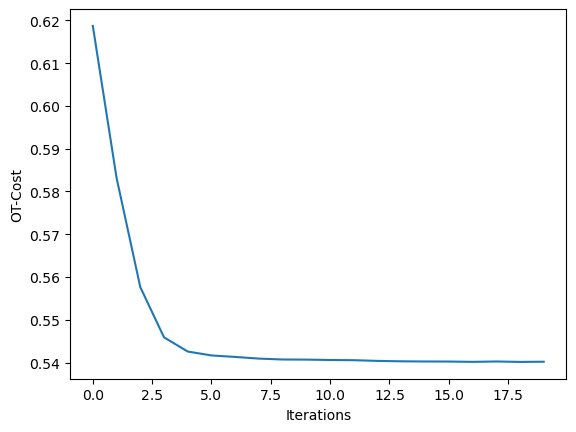

Cost of K-mpp init: 0.563688542959763
K-means cost of gkms with K-mpp init: 0.5401865395246523
Cost of Lloyds with K-mpp init: 0.5592775382418831
tensor([0.0004, 0.0004, 0.0004,  ..., 0.0004, 0.0004, 0.0004],
       dtype=torch.float64)
tensor([0.0004, 0.0004, 0.0004,  ..., 0.0004, 0.0004, 0.0004],
       dtype=torch.float64)
tensor([0.0004, 0.0004, 0.0004,  ..., 0.0004, 0.0004, 0.0004],
       dtype=torch.float64)
tensor([0.0004, 0.0004, 0.0004,  ..., 0.0004, 0.0004, 0.0004],
       dtype=torch.float64)


In [5]:

X = np.asarray(x0, dtype=float)
rng = np.random.default_rng(42)
centers = _kmeanspp_init_np(X, r, rng)
d2 = np.sum((x0[:, None, :] - centers[None, :, :])**2, axis=2)
labels = np.argmin(d2, axis=1)

Q = jnp.zeros((n, r))
Q1_kmpp = Q.at[jnp.arange(n), labels].set(1.0)
Q1_kmpp = to_torch( Q1_kmpp / jnp.sum(Q1_kmpp), device=torch_device, dtype=torch_dtype)
g1_kmpp = torch.sum(Q1_kmpp, axis=0)

C_X = distance.cdist(x0, x0)**2
C_X = C_X / C_X.max()
C_X = to_torch(C_X, device=torch_device, dtype=torch_dtype)


P_gkms, errs = gkms.GKMS_opt(C_X, Q1_kmpp, device=torch_device, r=r,
    max_iter=20, returnFull=True,
    gamma=70, max_inneriters_balanced=50,
    max_inneriters_relaxed=50,
    printCost=True
)

P_init = Q1_kmpp @ torch.diag(1.0 / g1_kmpp) @ Q1_kmpp.T
print(f'Cost of K-mpp init: {(P_init * C_X).sum().item()}')

print(f'K-means cost of gkms with K-mpp init: {(P_gkms * C_X).sum().item()}')

P_lloyd = Q1_t @ torch.diag(1.0 / g1_t) @ Q1_t.T
print(f'Cost of Lloyds with K-mpp init: {(P_lloyd * C_X).sum().item()}')

# Marginals good for all!
print(torch.sum(P_gkms, axis=0))
print(torch.sum(P_lloyd, axis=0))
print(torch.sum(P_gkms, axis=1))
print(torch.sum(P_lloyd, axis=1))

Iteration: 0


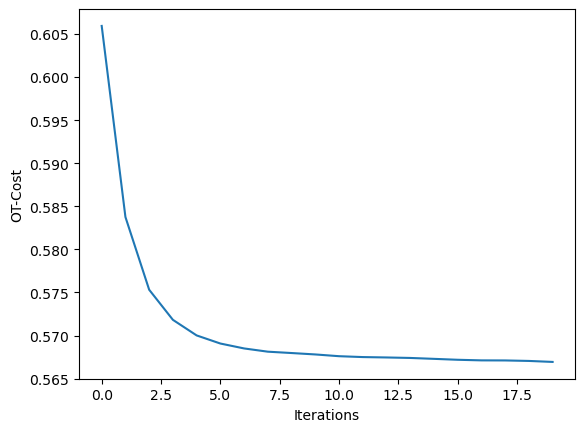

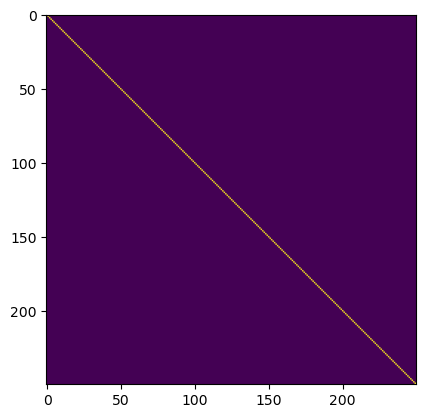

/tmp/ipykernel_475299/3268830402.py:16: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print(f'OT cost of FRLC with init 1: {(P * C).sum().item()}')


OT cost of FRLC with init 1: 0.5669425002968477
Iteration: 0


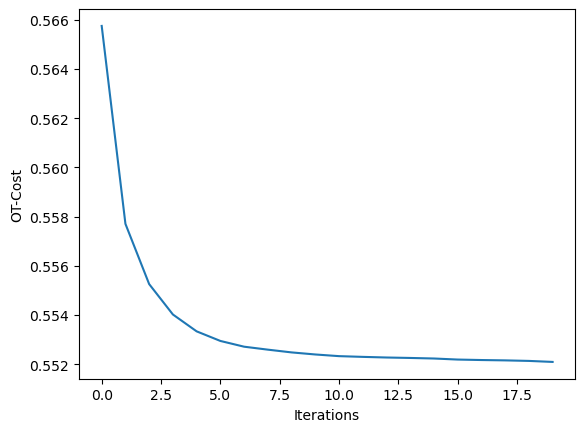

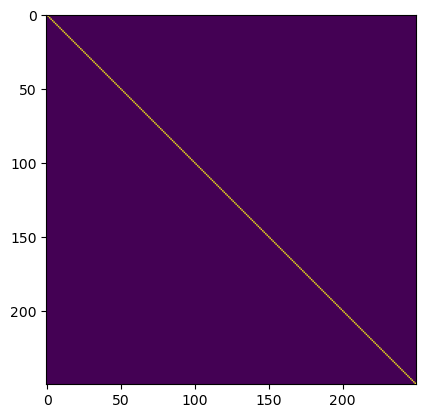

/tmp/ipykernel_475299/3268830402.py:26: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print(f'OT cost of FRLC with init 2: {(P * C).sum().item()}')


OT cost of FRLC with init 2: 0.5520946663020445
Iteration: 0


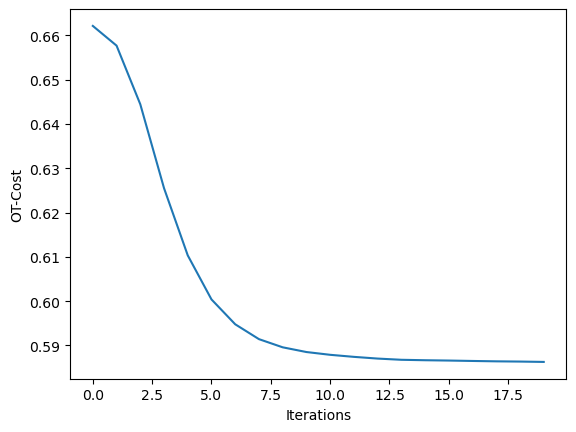

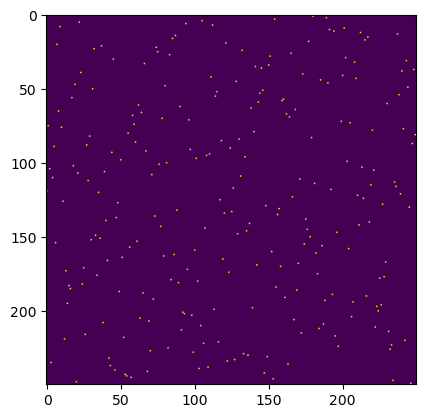

OT cost of FRLC with random init: 0.5862847576706596


/tmp/ipykernel_475299/3268830402.py:34: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print(f'OT cost of FRLC with random init: {(P * C).sum().item()}')


In [79]:
importlib.reload(gkms)

perm, P_dagger = gkms.monge_permutation(C)
C_t_dag = C @ P_dagger.T
C_t_dag = to_torch(C_t_dag, device=torch_device, dtype=torch_dtype)

P, errs = frlc.FRLC_opt(
    C_t, device=torch_device, r=r,
    max_iter=20, returnFull=True,
    gamma=70, max_inneriters_balanced=50,
    max_inneriters_relaxed=50,
    init_args=(Q1_t, R1_t, torch.diag(g1_t)),
    printCost=True
)

print(f'OT cost of FRLC with init 1: {(P * C).sum().item()}')

P, errs = frlc.FRLC_opt(
    C_t, device=torch_device, r=r,
    max_iter=20, returnFull=True,
    gamma=70, max_inneriters_balanced=50,
    max_inneriters_relaxed=50,
    init_args=(Q2_t, R2_t, torch.diag(g2_t)),
    printCost=True
)
print(f'OT cost of FRLC with init 2: {(P * C).sum().item()}')

P, errs = frlc.FRLC_opt(
    C_t, device=torch_device, r=r,
    max_iter=20, returnFull=True,
    gamma=70, max_inneriters_balanced=50,
    max_inneriters_relaxed=50, printCost=True)

print(f'OT cost of FRLC with random init: {(P * C).sum().item()}')


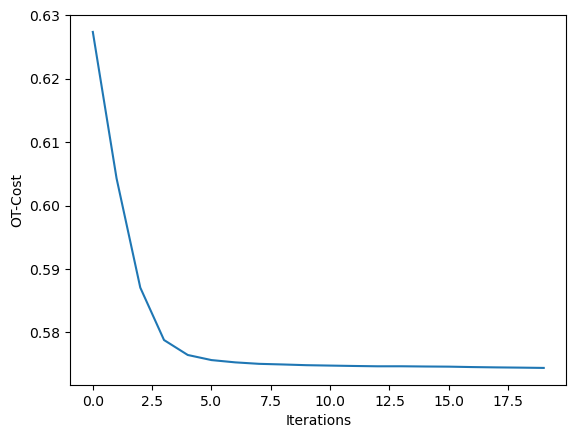

OT cost of GKMS with init 1: 0.5743955417204694


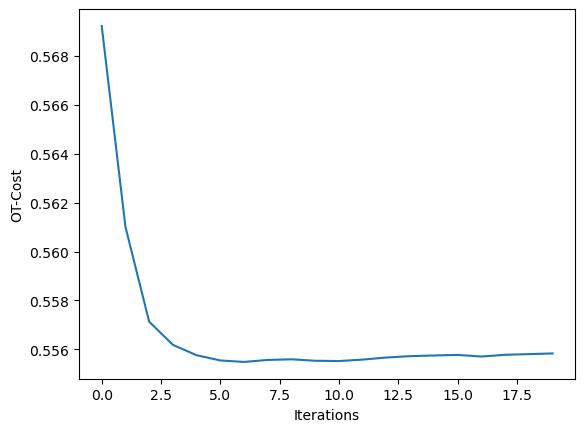

OT cost of GKMS with init 2: 0.5558298299518103


In [80]:
importlib.reload(gkms)

P, errs = gkms.GKMS_opt(
    C_t_dag, Q1_t, device=torch_device, r=r,
    max_iter=20, returnFull=True,
    gamma=70, max_inneriters_balanced=50,
    max_inneriters_relaxed=50, printCost=True)

print(f'OT cost of GKMS with init 1: {(P * C_t_dag).sum().item()}')

P, errs = gkms.GKMS_opt(
    C_t_dag, R2_t, device=torch_device, r=r,
    max_iter=20, returnFull=True,
    gamma=70, max_inneriters_balanced=50,
    max_inneriters_relaxed=50, printCost=True)

print(f'OT cost of GKMS with init 2: {(P * C_t_dag).sum().item()}')
